In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss,balanced_accuracy_score,classification_report
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer,make_column_selector
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import os
import warnings
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

/home/pgcp-ai/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
hr = pd.read_csv("HR_comma_sep.csv")
hr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.10,0.77,6,247,4,0,1,0,sales,low
3,0.92,0.85,5,259,5,0,1,0,sales,low
4,0.89,1.00,5,224,5,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14990,0.40,0.57,2,151,3,0,1,0,support,low
14991,0.37,0.48,2,160,3,0,1,0,support,low
14992,0.37,0.53,2,143,3,0,1,0,support,low
14993,0.11,0.96,6,280,4,0,1,0,support,low


In [3]:
ohe = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore').set_output(transform='pandas')
transformer = ColumnTransformer([
    
    (
        "OHE",
        ohe,
        make_column_selector(dtype_include=object)
    ),
    
],remainder='passthrough',verbose_feature_names_out=False).set_output(transform="pandas")
ss = StandardScaler()

In [4]:
X,y = hr.drop('left',axis=1), hr['left']

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=26,stratify=y)

In [6]:
n_estimators = [10, 25, 50, 75, 100]
rate = np.linspace(0.0001, 0.9, 30)
depth = [2, 3, 4, 5, 6]
scores = []

for n in tqdm(n_estimators):
    for r in rate:
        for d in depth:
            gbm = XGBClassifier(random_state=26, n_estimators=n, learning_rate=r, max_depth=d)
            pipe = Pipeline(
        [
            (
                "OHE",
                transformer
            ),
            (
                "GBM",
                gbm
            )
        ])
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            y_pred_prob = pipe.predict_proba(X_test)
            scores.append([n, r, d, log_loss(y_test, y_pred_prob), accuracy_score(y_test, y_pred)])
            
df_scores = pd.DataFrame(scores, columns = ["Number Of Estimators", "Learning Rate", "Depth", "Log Loss", "Accuracy Score"])
df_scores.sort_values(["Log Loss", "Accuracy Score"], ascending = [True, False])

100%|████████████████| 5/5 [01:26<00:00, 17.27s/it]


,Number Of Estimators,Learning Rate,Depth,Log Loss,Accuracy Score
419,50,0.713814,6,0.052566,0.989553
269,25,0.713814,6,0.054197,0.987108
424,50,0.744845,6,0.054880,0.988220
519,75,0.403503,6,0.055592,0.987108
669,100,0.403503,6,0.055968,0.986886
...,...,...,...,...,...
4,10,0.000100,6,0.548995,0.762169
3,10,0.000100,5,0.549010,0.762169
2,10,0.000100,4,0.549035,0.762169
1,10,0.000100,3,0.549090,0.762169


In [7]:
bm = XGBClassifier(learning_rate=0.124224,max_depth=6,n_estimators=100,random_state=26)
pipe = Pipeline(
        [
            (
                "OHE",
                transformer
            ),
            (
                "GBM",
                bm
            )
        ])
pipe.fit(X,y)

Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f91a40f06a0>)],
                                   verbose_feature_names_out=False)),
                ('GBM',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.124224, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=6,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=100,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=26, ...))])

In [8]:
bm.feature_importances_

array([0.00609453, 0.00928976, 0.01794245, 0.00924254, 0.        ,
       0.00888636, 0.01663409, 0.01244448, 0.0127786 , 0.02201884,
       0.0191818 , 0.30096415, 0.09617928, 0.10503425, 0.04414932,
       0.27713802, 0.03093179, 0.01108979], dtype=float32)

In [9]:
X_transform = transformer.fit_transform(X)
X_transform.columns

Index(['Department_RandD', 'Department_accounting', 'Department_hr',
       'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical', 'salary_low', 'salary_medium',
       'satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years'],
      dtype='object')

In [10]:
df = pd.DataFrame({"Feature" : X_transform.columns, "Importance" : bm.feature_importances_})
df = df.sort_values('Importance',ascending=False)

<Axes: xlabel='Importance', ylabel='Feature'>

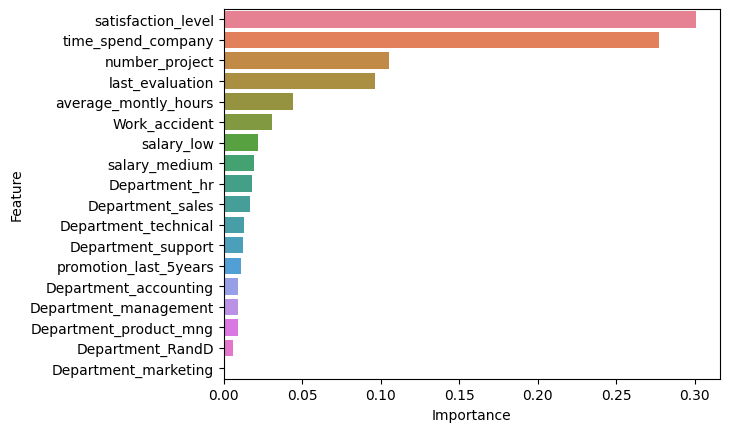

In [11]:
sns.barplot(data=df,x='Importance',y='Feature',hue='Feature')